In [1]:
%%capture
!pip install facenet-pytorch

## Libraries

In [2]:
import sys
sys.path.append('/home/pj00/projects/Github/small_face_recognition_trcking/utils')

In [278]:
import numpy as np
import cv2
import os
import time
import torch
import torch.nn as nn
from tqdm import tqdm
import torchvision
from PIL import Image
from torchvision import transforms
from torchvision.transforms.functional import to_pil_image
from facenet_pytorch import MTCNN, InceptionResnetV1, fixed_image_standardization, training
from custom_model import distill_model, distill_model_2
from torch.utils.data import Subset, DataLoader
from image_iter import FaceDataset, customSubset
from torch.utils.tensorboard import SummaryWriter
from torch import optim
from torch.optim.lr_scheduler import MultiStepLR
from torchsummary import summary



from utils import extract_face, take_picture, detect_crop_image, next_folder_name, aug_img, create_neg_class, model_size

%matplotlib inline
import matplotlib.pyplot as plt

## Functions

In [105]:
def create_class_data(data_folder, num_classes, num_images, aug_transform, dataset, idx_dict, model, crop_transform, device):
    class_path = []

    if num_classes == 1:
        path = os.path.join(data_folder, '{}'.format(next_folder_name(data_folder)))
        class_path.append(path)
        try:
            os.mkdir(path)
        except:
            print('Path exists: Issue!')
        create_neg_class(path, num_images, aug_transform, dataset, idx_dict) # add 50 random images

        frame, save_path = extract_face(save_path=data_folder)
        class_path.append(save_path)
        save_path = os.path.join(save_path, '0.jpg')
        images = detect_crop_image(frame=frame, model=mtcnn, transform=transform, device=device)
        pil_image = to_pil_image(images[0].detach().cpu())
        pil_image.save(save_path)
        aug_img(save_path=save_path, transform=aug_transform, num_images=num_images)

    else:
        pass
    
    return class_path

In [106]:
def save_model(model, model_name, optimizer_name, epoch, model_weight_path):
    os.makedirs(model_weight_path, exist_ok=True)  # Create ckpt directory if it doesn't exist
    file_name = f"{model_name}_{optimizer_name}_{epoch}.pt"
    save_path = os.path.join(model_weight_path, file_name)
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")


## Constants

In [368]:
BATCH_SIZE = 32
data_path = '/home/pj00/projects/Github/small_face_recognition_trcking/Data/finetuning_data/train'
data_path_val = '/home/pj00/projects/Github/small_face_recognition_trcking/Data/finetuning_data/val'
train_root = '/home/pj00/projects/Github/small_face_recognition_trcking/Data/CASIA/casia-webface/train.rec'
num_classes = 1
num_images = 1024
epochs = 8

## Models

In [369]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [370]:
mtcnn = MTCNN(
    image_size=112,
    margin=0,
    min_face_size=20,
    thresholds=[0.6, 0.7, 0.7],
    factor=0.709,
    post_process=False,
    device=device
)

In [399]:
del resnet

In [400]:
resnet = InceptionResnetV1(
    classify=True,
    pretrained='casia-webface',
    num_classes=2
).to(device)

In [401]:
del student, student_class

In [402]:
student = distill_model().to(device)
weight_path = '/home/pj00/projects/Github/small_face_recognition_trcking/model-weights/mobV3_adam_29.pt'
student.load_state_dict(torch.load(weight_path))

<All keys matched successfully>

In [403]:
# for param in student.parameters():
#     param.requires_grad = False

In [404]:
student_class = nn.Sequential(student, nn.Hardswish(), nn.Dropout(p=0.2, inplace=True), nn.Linear(512, 2))

In [405]:
# student.final = nn.Linear(512, 2)

In [406]:
student_class.to(device)
print('Done')
# for name, param in student_class.named_parameters():
#     if param.requires_grad:
#         print(name)

Done


In [407]:
model_size(student_class)

model size: 65397824 / bit | 8.17 / MB


## Transforms

In [334]:
transform = transforms.Compose([
            transforms.Resize((112, 112)),
            transforms.ToTensor(),
        ])

In [335]:
aug_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=.5, hue=.3),
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5.)), 
    transforms.RandomAutocontrast(),
    transforms.ToPILImage()])

In [336]:
train_dataset_transform = transforms.Compose([
    transforms.ToTensor(),
])

## Create Dataset

In [17]:
dataset = FaceDataset(path_imgrec=train_root, rand_mirror=True)

/home/pj00/projects/Github/small_face_recognition_trcking/Data/CASIA/casia-webface/train.rec /home/pj00/projects/Github/small_face_recognition_trcking/Data/CASIA/casia-webface/train.idx
header0 label [490624. 501196.]
id2range 10572


In [18]:
ss = customSubset(train_root)
idx_dict = ss.generate_idx_dic()

In [381]:
class_paths = create_class_data(data_folder=data_path, 
                                num_classes=num_classes, 
                                num_images=num_images, 
                                aug_transform=aug_transform, 
                                dataset=dataset, 
                                idx_dict=idx_dict, 
                                model=mtcnn, 
                                crop_transform=transform, 
                                device=device)

[ WARN:0@8334.774] global /croot/opencv-suite_1691620365762/work/modules/videoio/src/cap_gstreamer.cpp (862) isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created


Photo taken!


In [382]:
class_paths = create_class_data(data_folder=data_path_val, 
                                num_classes=num_classes, 
                                num_images=num_images, 
                                aug_transform=aug_transform, 
                                dataset=dataset, 
                                idx_dict=idx_dict, 
                                model=mtcnn, 
                                crop_transform=transform, 
                                device=device)

[ WARN:0@8382.383] global /croot/opencv-suite_1691620365762/work/modules/videoio/src/cap_gstreamer.cpp (862) isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created


Photo taken!


In [391]:
train_dataset = torchvision.datasets.ImageFolder(
    root=data_path,
    transform=train_dataset_transform
)

In [392]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True)

In [393]:
val_dataset = torchvision.datasets.ImageFolder(
    root=data_path_val,
    transform=train_dataset_transform
)

In [394]:
val_loader = DataLoader(
    val_dataset, 
    batch_size=1, 
    shuffle=True)

## Finetuning

### Finetuning Resnet

In [408]:
model_weight_path = '/home/pj00/projects/Github/small_face_recognition_trcking/model-weights/finetuned/resnet'

In [409]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.parameters(), lr=0.001)
scheduler = MultiStepLR(optimizer, [5, 10])

In [410]:
# losses = []
# for epoch in tqdm(range(epochs)):
#     epoch_loss = 0
#     for x, y in train_loader:
#         resnet.train()
#         x = x.to(device)
#         y = y.to(device)
#         y_pred = resnet(x)
#         loss_batch = loss_fn(y_pred, y)
#         optimizer.zero_grad()
#         loss_batch.backward()
#         optimizer.step()

#         epoch_loss += loss_batch.item()

#     epoch_loss /= len(train_loader)
#     losses.append(epoch_loss)
#     print('Epoch_loss: {}'.format(epoch_loss))
    
#     scheduler.step()
    
#     save_model(resnet, model_name='resnet', optimizer_name='adam', epoch=str(epoch+1), model_weight_path=model_weight_path)

In [411]:
# Lists to store training and validation losses
train_losses = []
val_losses = []

for epoch in tqdm(range(epochs)):
    # Training phase
    resnet.train()
    epoch_loss = 0
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        y_pred = resnet(x)
        loss_batch = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss_batch.backward()
        optimizer.step()
        epoch_loss += loss_batch.item()

    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)
    print('Epoch [{}], Training Loss: {:.4f}'.format(epoch + 1, epoch_loss))

    # Validation phase
    resnet.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val = x_val.to(device)
            y_val = y_val.to(device)
            y_val_pred = resnet(x_val)
            loss_val_batch = loss_fn(y_val_pred, y_val)
            val_loss += loss_val_batch.item()
            _, predicted = torch.max(y_val_pred.data, 1)
            total += y_val.size(0)
            correct += (predicted == y_val).sum().item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    val_accuracy = 100 * correct / total
    print('Epoch [{}], Validation Loss: {:.4f}, Validation Accuracy: {:.2f}%'.format(epoch + 1, val_loss, val_accuracy))

    # Optionally step the scheduler
    # scheduler.step()
    
    # Save the model
    save_model(resnet, model_name='resnet', optimizer_name='adam', epoch=str(epoch + 1), model_weight_path=model_weight_path)


  0%|                                                     | 0/8 [00:00<?, ?it/s]

Epoch [1], Training Loss: 0.0182
Epoch [1], Validation Loss: 0.0021, Validation Accuracy: 100.00%


 12%|█████▋                                       | 1/8 [00:53<06:14, 53.44s/it]

Model saved to /home/pj00/projects/Github/small_face_recognition_trcking/model-weights/finetuned/resnet/resnet_adam_1.pt
Epoch [2], Training Loss: 0.0000
Epoch [2], Validation Loss: 0.0082, Validation Accuracy: 99.80%


 25%|███████████▎                                 | 2/8 [01:49<05:29, 54.89s/it]

...

Model saved to /home/pj00/projects/Github/small_face_recognition_trcking/model-weights/finetuned/resnet/resnet_adam_6.pt
Epoch [7], Training Loss: 0.0000
Epoch [7], Validation Loss: 0.0018, Validation Accuracy: 99.95%


 88%|███████████████████████████████████████▍     | 7/8 [06:39<00:58, 58.04s/it]

Model saved to /home/pj00/projects/Github/small_face_recognition_trcking/model-weights/finetuned/resnet/resnet_adam_7.pt
Epoch [8], Training Loss: 0.0000
Epoch [8], Validation Loss: 0.0016, Validation Accuracy: 100.00%


100%|█████████████████████████████████████████████| 8/8 [07:39<00:00, 57.46s/it]

Model saved to /home/pj00/projects/Github/small_face_recognition_trcking/model-weights/finetuned/resnet/resnet_adam_8.pt


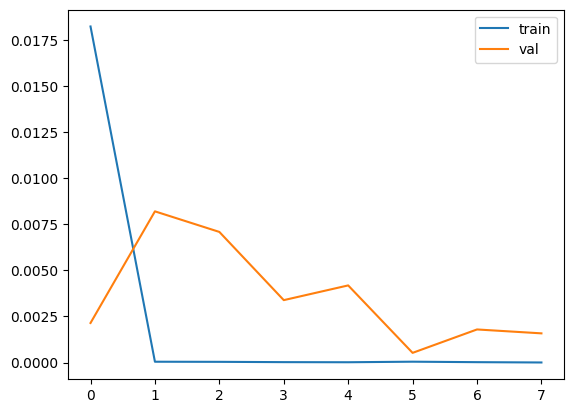

In [413]:
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.legend()
plt.show()

### Finetuned MobileNetV3

In [425]:
del student, student_class

student = distill_model().to(device)
weight_path = '/home/pj00/projects/Github/small_face_recognition_trcking/model-weights/mobV3_adam_29.pt'
student.load_state_dict(torch.load(weight_path))

student_class = nn.Sequential(student, nn.Hardswish(), nn.Dropout(p=0.2, inplace=True), nn.Linear(512, 2))

student_class.to(device)
print('Done')
# for name, param in student_class.named_parameters():
#     if param.requires_grad:
#         print(name)

Done


In [426]:
model_weight_path = '/home/pj00/projects/Github/small_face_recognition_trcking/model-weights/finetuned/mobV3'

In [427]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(student_class.parameters(), lr=0.01, momentum=0.9)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5, verbose=True)

In [428]:
# losses = []
# for epoch in tqdm(range(epochs)):
#     epoch_loss = 0
#     student_class.train()
#     for x, y in train_loader:
#         x = x.to(device)
#         y = y.to(device)
#         y_pred = student_class(x)
#         loss_batch = loss_fn(y_pred, y)
#         optimizer.zero_grad()
#         loss_batch.backward()
#         optimizer.step()

#         epoch_loss += loss_batch.item()

#     epoch_loss /= len(train_loader)
#     losses.append(epoch_loss)
#     print('Epoch_loss: {}'.format(epoch_loss))
    
# #     scheduler.step()
    
#     save_model(student_class, model_name='mobV3', optimizer_name='adam', epoch=str(epoch+1), model_weight_path=model_weight_path)

In [429]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=16, 
    shuffle=True)

In [430]:
# Lists to store training and validation losses
train_losses = []
val_losses = []

for epoch in tqdm(range(epochs)):
    # Training phase
    student_class.train()
    epoch_loss = 0
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        y_pred = student_class(x)
        loss_batch = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss_batch.backward()
        optimizer.step()
        epoch_loss += loss_batch.item()

    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)
    print('Epoch [{}], Training Loss: {:.4f}'.format(epoch + 1, epoch_loss))

    # Validation phase
    student_class.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val = x_val.to(device)
            y_val = y_val.to(device)
            y_val_pred = student_class(x_val)
            loss_val_batch = loss_fn(y_val_pred, y_val)
            val_loss += loss_val_batch.item()
            _, predicted = torch.max(y_val_pred.data, 1)
            total += y_val.size(0)
            correct += (predicted == y_val).sum().item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    val_accuracy = 100 * correct / total
    print('Epoch [{}], Validation Loss: {:.4f}, Validation Accuracy: {:.2f}%'.format(epoch + 1, val_loss, val_accuracy))

    # Optionally step the scheduler
    # scheduler.step()
    
    # Save the model
    save_model(student_class, model_name='mobV3', optimizer_name='sgd', epoch=str(epoch + 1), model_weight_path=model_weight_path)


  0%|                                                     | 0/8 [00:00<?, ?it/s]

Epoch [1], Training Loss: 0.6913


 12%|█████▋                                       | 1/8 [00:16<01:53, 16.23s/it]

Epoch [1], Validation Loss: 0.6945, Validation Accuracy: 50.00%
Model saved to /home/pj00/projects/Github/small_face_recognition_trcking/model-weights/finetuned/mobV3/mobV3_sgd_1.pt
Epoch [2], Training Loss: 0.6819


 25%|███████████▎                                 | 2/8 [00:33<01:40, 16.75s/it]

...

Epoch [6], Validation Loss: 0.2776, Validation Accuracy: 93.41%
Model saved to /home/pj00/projects/Github/small_face_recognition_trcking/model-weights/finetuned/mobV3/mobV3_sgd_6.pt
Epoch [7], Training Loss: 0.0067


 88%|███████████████████████████████████████▍     | 7/8 [02:00<00:17, 17.51s/it]

Epoch [7], Validation Loss: 0.3036, Validation Accuracy: 77.69%
Model saved to /home/pj00/projects/Github/small_face_recognition_trcking/model-weights/finetuned/mobV3/mobV3_sgd_7.pt
Epoch [8], Training Loss: 0.0030


100%|█████████████████████████████████████████████| 8/8 [02:18<00:00, 17.26s/it]

Epoch [8], Validation Loss: 0.0990, Validation Accuracy: 97.17%
Model saved to /home/pj00/projects/Github/small_face_recognition_trcking/model-weights/finetuned/mobV3/mobV3_sgd_8.pt


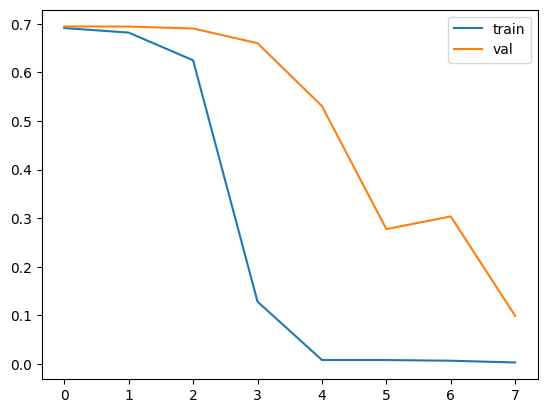

In [431]:
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.legend()
plt.show()